In [1]:
!rm -rf prism-xai

In [2]:
import os

if not os.path.exists("/content/prism-xai"):
    !git clone https://github.com/shriyanssahoo/prism-xai.git
    %cd /content/prism-xai
else:
    %cd /content/prism-xai
    !git pull

!pip install -r requirements.txt

Cloning into 'prism-xai'...
remote: Enumerating objects: 186, done.
remote: Counting objects: 100% (186/186), done.
remote: Compressing objects: 100% (176/176), done.
remote: Total 186 (delta 10), reused 183 (delta 7), pack-reused 0 (from 0)
Receiving objects: 100% (186/186), 14.56 MiB | 18.90 MiB/s, done.
Resolving deltas: 100% (10/10), done.
/content/prism-xai
ERROR: Could not find a version that satisfies the requirement pytorch-grad-cam>=1.4.8 (from versions: none)
ERROR: No matching distribution found for pytorch-grad-cam>=1.4.8


In [3]:
import torch
import numpy as np
import random

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

print(f"Random seed set to {SEED}")

Random seed set to 42


In [4]:
import sys
for mod_name in list(sys.modules.keys()):
    if mod_name.startswith("src"):
        del sys.modules[mod_name]

from src.model_utils import load_model, load_image, get_vgg16_last_conv_layer, ActivationExtractor
from src.prism import compute_prism
from src.visualize import plot_prism_batch
from src.variance_analysis import plot_variance_distribution, compare_batch_sizes

import glob

print("All imports successful")

All imports successful


In [5]:
model = load_model("vgg16")
layer = get_vgg16_last_conv_layer(model)
extractor = ActivationExtractor(model, layer)

print("Model loaded, hook attached")

Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:03<00:00, 157MB/s]


Model loaded, hook attached


In [6]:
!ls data/raw/

bagel	       coyote		    passenger_car	siberian_husky
black_widow    electric_locomotive  prepare_dataset.py	steam_locomotive
border_collie  garden_spider	    red_wolf		timber_wolf
cheeseburger   grey_fox		    samoyed


In [7]:
small_batch_paths = (
    glob.glob("data/raw/timber_wolf/*")[:2] +
    glob.glob("data/raw/coyote/*")[:1]
)
print("Small batch paths:", small_batch_paths)

tensors_small = [load_image(p)[0] for p in small_batch_paths]
batch_small = torch.stack(tensors_small).to(next(model.parameters()).device)

with torch.no_grad():
    model(batch_small)

prism_maps_small, top3_var_small, all_var_small = compute_prism(extractor.activations)

print("PRISM map shape:", prism_maps_small.shape)
print("Top-3 PC variance:", top3_var_small, "sum:", top3_var_small.sum())

Small batch paths: ['data/raw/timber_wolf/n02114548_10024.JPEG', 'data/raw/timber_wolf/n02114548_10093.JPEG', 'data/raw/coyote/n02114855_10035.JPEG']
PRISM map shape: (3, 3, 14, 14)
Top-3 PC variance: [0.25281637 0.14438103 0.07728306] sum: 0.47448046021776147


Saved to results/figures/variance_2class.png


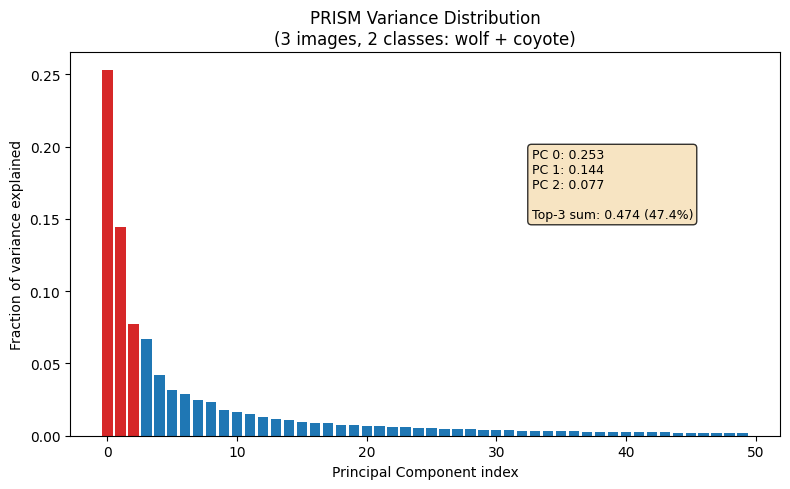

np.float64(0.47448046021776147)

In [8]:
os.makedirs("results/figures", exist_ok=True)

plot_variance_distribution(
    all_var_small,
    top_n_pcs=3,
    title="PRISM Variance Distribution\n(3 images, 2 classes: wolf + coyote)",
    save_path="results/figures/variance_2class.png"
)

In [9]:
large_batch_paths = (
    glob.glob("data/raw/timber_wolf/*")[:2] +
    glob.glob("data/raw/coyote/*")[:2] +
    glob.glob("data/raw/grey_fox/*")[:2] +
    glob.glob("data/raw/border_collie/*")[:2] +
    glob.glob("data/raw/samoyed/*")[:2]
)
print(f"Total images in 5-class batch: {len(large_batch_paths)}")
print(large_batch_paths)

tensors_large = [load_image(p)[0] for p in large_batch_paths]
batch_large = torch.stack(tensors_large).to(next(model.parameters()).device)

with torch.no_grad():
    model(batch_large)

prism_maps_large, top3_var_large, all_var_large = compute_prism(extractor.activations)

print("PRISM map shape:", prism_maps_large.shape)
print("Top-3 PC variance:", top3_var_large, "sum:", top3_var_large.sum())

Total images in 5-class batch: 10
['data/raw/timber_wolf/n02114548_10024.JPEG', 'data/raw/timber_wolf/n02114548_10093.JPEG', 'data/raw/coyote/n02114855_10035.JPEG', 'data/raw/coyote/n02114855_10105.JPEG', 'data/raw/grey_fox/n02120505_10115.JPEG', 'data/raw/grey_fox/n02120505_10036.JPEG', 'data/raw/border_collie/n02106166_1024.JPEG', 'data/raw/border_collie/n02106166_1.JPEG', 'data/raw/samoyed/n02111889_4757.JPEG', 'data/raw/samoyed/n02111889_5787.JPEG']
PRISM map shape: (10, 3, 14, 14)
Top-3 PC variance: [0.16876975 0.08560214 0.07157477] sum: 0.32594665752706886


Saved to results/figures/variance_5class.png


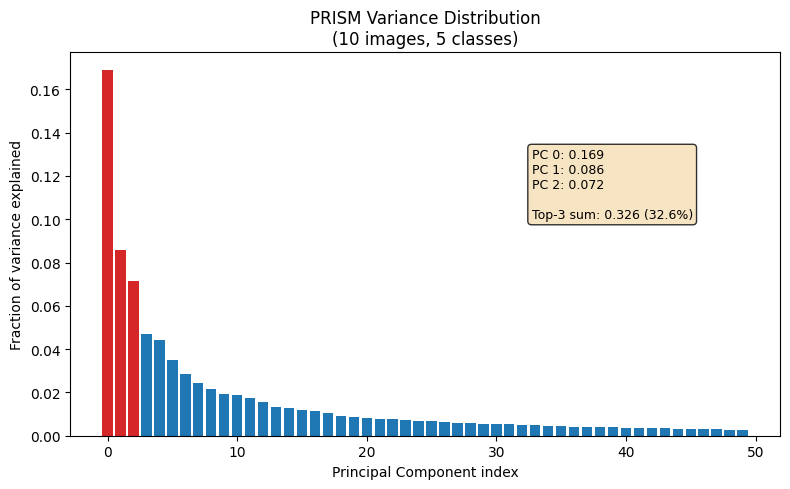

np.float64(0.32594665752706886)

In [10]:
plot_variance_distribution(
    all_var_large,
    top_n_pcs=3,
    title="PRISM Variance Distribution\n(10 images, 5 classes)",
    save_path="results/figures/variance_5class.png"
)

Saved to results/figures/variance_comparison.png


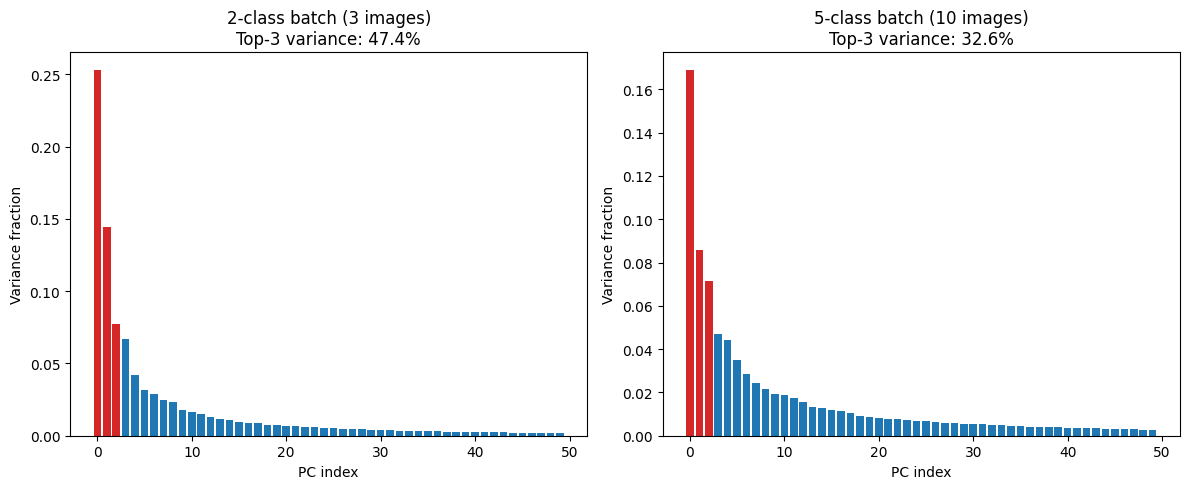


Summary — Top-3 PC variance captured:
  2-class batch (3 images): 47.4%
  5-class batch (10 images): 32.6%


In [11]:
results = {
    "2-class batch (3 images)": all_var_small,
    "5-class batch (10 images)": all_var_large,
}

summary = compare_batch_sizes(
    results,
    top_n_pcs=3,
    save_path="results/figures/variance_comparison.png"
)

print("\nSummary — Top-3 PC variance captured:")
for label, value in summary.items():
    print(f"  {label}: {value*100:.1f}%")

In [12]:
import csv

os.makedirs("results/tables", exist_ok=True)

with open("results/tables/variance_summary.csv", "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(["Batch", "Num Images", "Top-3 PC Variance (%)"])
    writer.writerow(["2-class (wolf, coyote)", len(small_batch_paths), f"{summary['2-class batch (3 images)']*100:.2f}"])
    writer.writerow(["5-class (wolf, coyote, grey_fox, border_collie, samoyed)", len(large_batch_paths), f"{summary['5-class batch (10 images)']*100:.2f}"])

print("Saved results/tables/variance_summary.csv")
!cat results/tables/variance_summary.csv

Saved results/tables/variance_summary.csv
Batch,Num Images,Top-3 PC Variance (%)
"2-class (wolf, coyote)",3,47.45
"5-class (wolf, coyote, grey_fox, border_collie, samoyed)",10,32.59
